# 1. Exploratory Data Analysis (EDA) & Initial Profiling

**Context**: Before merging our localized Jumia datasets with behavioral streams, we must establish a baseline for data quality and class distribution. This phase identifies the "Information Asymmetry" targets where numerical metrics might mask qualitative issues..

## 1.1 Environment & Data Acquisition

We leverage a modular DataLoader (located in src/) to ingest three distinct data streams. This separation of concerns ensures that ingestion logic remains decoupled from the analytical narrative.

In [2]:
import sys

sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_preprocessing import DataLoader

# Standardization of visualization for stakeholder consistency
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Ingesting partitioned datasets
loader = DataLoader(data_dir="../data/")
behavioral = loader.load_behavioral_data()
products = loader.load_product_data()
reviews = loader.load_reviews_data()

Loaded behavioral data: (8000, 14)
Loaded product data: (100, 20)
Loaded reviews data: (100, 7)


## 1.2 Behavioral Stream: Quantifying the Conversion Gap

The behavioral data tracks user sessions. Our primary objective is to evaluate the Class Imbalance in the purchase target. In high-traffic e-commerce environments, non-purchase events vastly outnumber conversions; however, extreme skew (e.g., 99:1) will dictate our requirement for SMOTE (Synthetic Minority Over-sampling Technique) in later stages.

Dataset Dimensions: (8000, 14)
Missing Values:
user_id               160
age                   160
gender                160
device_type           160
time_on_site          160
pages_viewed          160
previous_purchases    160
cart_items            160
discount_seen         160
ad_clicked            160
returning_user        160
avg_session_time      160
bounce_rate           160
purchase              160
dtype: int64

Purchase distribution:
purchase
1.0    7827
0.0      13
Name: count, dtype: int64
Imbalance ratio: 0.00:1


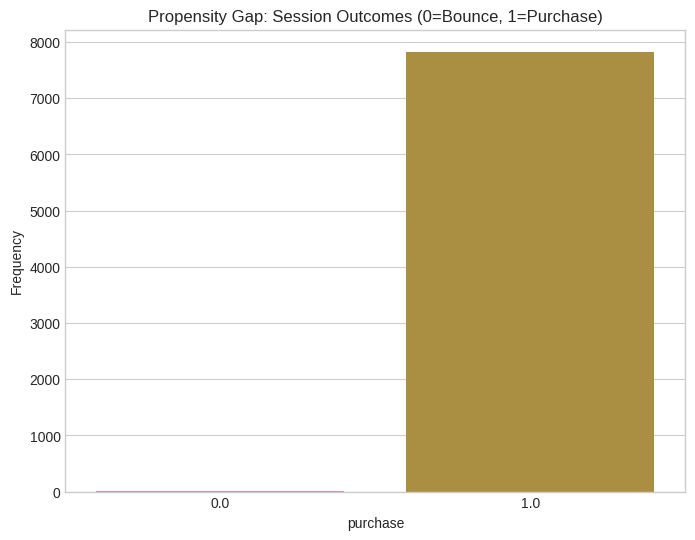

In [3]:
# Technical Profile: Behavioral Data
print(f"Dataset Dimensions: {behavioral.shape}")
print(f"Missing Values:\n{behavioral.isnull().sum()}")

# Imbalance Analysis
purchase_counts = behavioral["purchase"].value_counts()
ratio = purchase_counts[0] / purchase_counts[1]
print(f"\nPurchase distribution:\n{purchase_counts}")
print(f"Imbalance ratio: {ratio:.2f}:1")

# Visualizing the Propensity Gap
plt.figure(figsize=(8, 6))
sns.barplot(
    x=purchase_counts.index,
    y=purchase_counts.values,
    hue=purchase_counts.index,
    legend=False,
)
plt.title("Propensity Gap: Session Outcomes (0=Bounce, 1=Purchase)")
plt.ylabel("Frequency")
plt.show()

## 1.3 Product & Review Integrity: Detecting "Information Asymmetry"

The product and review datasets contain the "qualitative" heart of the project. We are inspecting these for two specific localized issues:

- **Currency Parsing Needs**: Identifying if final_price contains non-numeric characters (KSh) or ranges that require regex extraction.

- **Sentiment-Rating Gap**: Checking if star ratings (quantitative) might be contradicted by review text (qualitative), particularly those involving local dialects.

In [4]:
# Technical Profile: Products & Reviews
print(f"Product Categories: {products['product_category'].nunique()}")
print(f"Rating Distribution:\n{reviews['rating'].value_counts().sort_index()}")

# Inspecting Raw Formats for Pre-processing Needs
print("\n--- Pricing Format Check (KSh) ---")
print(products[["product_name", "final_price"]].head(3))

print("\n--- Review Text Sample (Linguistic Nuance) ---")
print(reviews[["rating", "review"]].head(3))

Product Categories: 1
Rating Distribution:
rating
1     5
2     2
3     8
4    23
5    62
Name: count, dtype: int64

--- Pricing Format Check (KSh) ---
                                        product_name final_price
0  Buy One Get One Free All-in-One Car Leather Cl...   KSh 2,199
1                     Pearl Pearl Pishori Rice - 2kg     KSh 589
2            Kabras Kabras Premium White Sugar - 2kg     KSh 249

--- Review Text Sample (Linguistic Nuance) ---
   rating                        review
0       4  It smells good and works ok.
1       5                  Good product
2       4                       Love it
